# AuthSys Ablation

In [53]:
DATASET_ORDER = [
    "F",
    "LAS",
    "D",
    "A",
    "AA",
    "RWA",
    "RWA3D",
    "KSA3",
    "ACT",
    "VSA",
    "ASC",
    "APC",
    "CSM",
    "DW",
    "BDW",
]

# OLMo family sorted by training stage (base -> post-training steps).
# All other models sorted by group lex, then name_short lex.
OLMO_ORDER = {
    "Olmo 3.1 32B": "Olmo00",
    "Olmo3 7B Base": "Olmo01",
    "Olmo3 7B Instruct SFT": "Olmo02",
    "Olmo3 7B Instruct DPO": "Olmo03",
    "Olmo3 7B Instruct RLVR": "Olmo04",
}


def model_sort_key(m):
    return (
        m["group"],
        OLMO_ORDER.get(m["name_short"], m["name_short"]),
    )

In [54]:
import pandas as pd

from llm_audit import BASE_DIR


tidy_construct_scores_path = BASE_DIR / "eval" / "data" / "tidy" / "construct_scores_ensemble.csv"
df = pd.read_csv(tidy_construct_scores_path)

print(df.columns)
# print(df.dtypes)
print(len(df))
print(df["experiment_type"].unique())
print(df["experiment_ablation"].unique())
print(df["dataset"].unique())

df.head()

Index(['model', 'dataset', 'statement_id', 'repetition_id', 'language',
       'experiment_type', 'experiment_ablation', 'score', 'refusal',
       'reverse_scored', 'factor', 'auth'],
      dtype='object')
433500
['open_question' 'closed_question']
['default' 'authsys' 'reverse']
['F' 'LAS' 'D' 'A' 'AA' 'RWA' 'RWA3D' 'KSA3' 'ACT' 'VSA' 'ASC' 'APC' 'CSM'
 'PI' 'DW' 'BDW' 'CW' 'SDO7' 'PISD' 'BFI10']


,model,dataset,statement_id,repetition_id,language,experiment_type,experiment_ablation,score,refusal,reverse_scored,factor,auth
0,Qwen/Qwen3-30B-A3B-Instruct-2507,F,1,0,en,open_question,default,-1.000000,0.0,0,NaN,0.0
1,Qwen/Qwen3-30B-A3B-Instruct-2507,F,1,1,en,open_question,default,-0.666667,0.0,0,NaN,0.0
2,Qwen/Qwen3-30B-A3B-Instruct-2507,F,1,2,en,open_question,default,-1.000000,0.0,0,NaN,0.0
3,Qwen/Qwen3-30B-A3B-Instruct-2507,F,1,3,en,open_question,default,-0.666667,0.0,0,NaN,0.0
4,Qwen/Qwen3-30B-A3B-Instruct-2507,F,1,4,en,open_question,default,-0.666667,0.0,0,NaN,0.0


In [55]:
import json
import numpy as np
import pandas as pd

from scipy.stats import wasserstein_distance, wilcoxon


with open(BASE_DIR / "resources" / "input" / "models" / "final_complete.json") as f:
    models = json.load(f)

models.sort(key=model_sort_key)

model_label_short_map = {m["name"]: m["name_short"] for m in models}
model_label_group_map = {m["name"]: m["group"] for m in models}
model_labels = [m["name"] for m in models]

AUTHSYS_ABLATION_OUTPUT_DIR = BASE_DIR / "eval" / "data" / "authsys_ablation"
AUTHSYS_ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tidy_construct_scores_path = BASE_DIR / "eval" / "data" / "tidy" / "construct_scores_ensemble.csv"
vignette_scores_path = BASE_DIR / "eval" / "data" / "tidy" / "vignette_scores.csv"

RESPONSE_LABEL_MAP = {
    "antiautho_high": -1.0,
    "antiautho_medium": -0.5,
    "neutral": 0.0,
    "autho_medium": 0.5,
    "autho_high": 1.0,
}

APPROACHES = {
    "closed_question": dict(
        csv=tidy_construct_scores_path,
        experiment_type="closed_question",
        dataset_filter=DATASET_ORDER,
        pivot_index=["dataset", "statement_id", "repetition_id"],
        score_col="score",
        label_map=None,
    ),
    "open_question": dict(
        csv=tidy_construct_scores_path,
        experiment_type="open_question",
        dataset_filter=DATASET_ORDER,
        pivot_index=["dataset", "statement_id", "repetition_id"],
        score_col="score",
        label_map=None,
    ),
    "behavioral": dict(
        csv=vignette_scores_path,
        experiment_type=None,
        dataset_filter=None,
        pivot_index=["dataset", "statement_id", "vignette_id", "repetition_id"],
        score_col="response_label",
        label_map=RESPONSE_LABEL_MAP,
    ),
}

B = 10_000
rng = np.random.default_rng(42)

for approach_name, cfg in APPROACHES.items():
    df_raw = pd.read_csv(cfg["csv"])

    if cfg["label_map"] is not None:
        df_raw = df_raw.copy()
        df_raw["score"] = df_raw[cfg["score_col"]].map(cfg["label_map"])

    results = []

    for model_label in model_labels:
        labels_to_keep = ["default", "authsys"]

        mask = (
            (df_raw["experiment_ablation"].isin(labels_to_keep))
            & (df_raw["model"] == model_label)
            & (df_raw["language"] == "en")
        )
        if cfg["dataset_filter"] is not None:
            mask &= df_raw["dataset"].isin(cfg["dataset_filter"])
        if cfg["experiment_type"] is not None:
            mask &= df_raw["experiment_type"] == cfg["experiment_type"]

        df_scope = df_raw[mask]

        refusal_rate_default = (df_scope[df_scope["experiment_ablation"] == "default"]["refusal"] == 1).mean()
        refusal_rate_authsys = (df_scope[df_scope["experiment_ablation"] == "authsys"]["refusal"] == 1).mean()

        df_filt = df_scope[df_scope["refusal"] == 0]

        paired = df_filt.pivot(
            index=cfg["pivot_index"],
            columns="experiment_ablation",
            values="score",
        )

        if not {"default", "authsys"}.issubset(paired.columns):
            print(
                f"  [{approach_name}] skipping {model_label_short_map[model_label]}: "
                f"expected columns 'default'/'authsys', "
                f"got {list(paired.columns) or '(empty)'}"
            )
            continue

        paired = paired.dropna(subset=["default", "authsys"])

        X = paired["default"].to_numpy()
        Y = paired["authsys"].to_numpy()
        diff = Y - X
        Z = np.concatenate([X, Y])
        n = len(X)
        assert len(X) == len(Y)

        wd_boot = np.empty(B)
        diff_mean_boot = np.empty(B)
        wd_extreme_boot = np.empty(B)
        mean_X_boot = np.empty(B)
        mean_Y_boot = np.empty(B)

        for b in range(B):
            wd_boot[b] = wasserstein_distance(
                rng.choice(Z, size=n, replace=True),
                rng.choice(Z, size=n, replace=True),
            )
            Xb = rng.choice(X, size=n, replace=True)
            Yb = rng.choice(Y, size=n, replace=True)
            mean_X_boot[b] = np.mean(Xb)
            mean_Y_boot[b] = np.mean(Yb)
            wd_extreme_boot[b] = wasserstein_distance(np.abs(Xb), np.abs(Yb))
            diff_mean_boot[b] = np.mean(rng.choice(diff, size=n, replace=True))

        default_estimate = np.mean(X)
        authsys_estimate = np.mean(Y)
        delta = authsys_estimate - default_estimate

        ci_default_low, ci_default_high = np.percentile(mean_X_boot, [2.5, 97.5])
        ci_authsys_low, ci_authsys_high = np.percentile(mean_Y_boot, [2.5, 97.5])
        ci_delta_low, ci_delta_high = np.percentile(diff_mean_boot, [2.5, 97.5])

        wd_obs = wasserstein_distance(X, Y)
        wd_paired = wasserstein_distance(np.zeros_like(diff), diff)
        wd_p = np.mean(wd_boot >= wd_obs)
        wd_extreme = wasserstein_distance(np.abs(X), np.abs(Y))
        ci_wd_extreme_low, ci_wd_extreme_high = np.percentile(wd_extreme_boot, [2.5, 97.5])
        _, p_wilcoxon = wilcoxon(diff)

        results.append(
            {
                "model": model_label,
                "model_label_short": model_label_short_map[model_label],
                "group": model_label_group_map[model_label],
                "n": n,
                "refusal_rate_default": refusal_rate_default,
                "refusal_rate_authsys": refusal_rate_authsys,
                "default_estimate": default_estimate,
                "default_ci_low": ci_default_low,
                "default_ci_high": ci_default_high,
                "authsys_estimate": authsys_estimate,
                "authsys_ci_low": ci_authsys_low,
                "authsys_ci_high": ci_authsys_high,
                "delta": delta,
                "ci_delta_low": ci_delta_low,
                "ci_delta_high": ci_delta_high,
                "wilcoxon_p": p_wilcoxon,
                "global_wd": wd_obs,
                "global_wd_p": wd_p,
                "paired_wd": wd_paired,
                "wd_extreme": wd_extreme,
                "wd_extreme_ci_low": ci_wd_extreme_low,
                "wd_extreme_ci_high": ci_wd_extreme_high,
            }
        )

    pd.DataFrame(results).to_csv(AUTHSYS_ABLATION_OUTPUT_DIR / f"stats_{approach_name}.csv", index=False)

## Figures

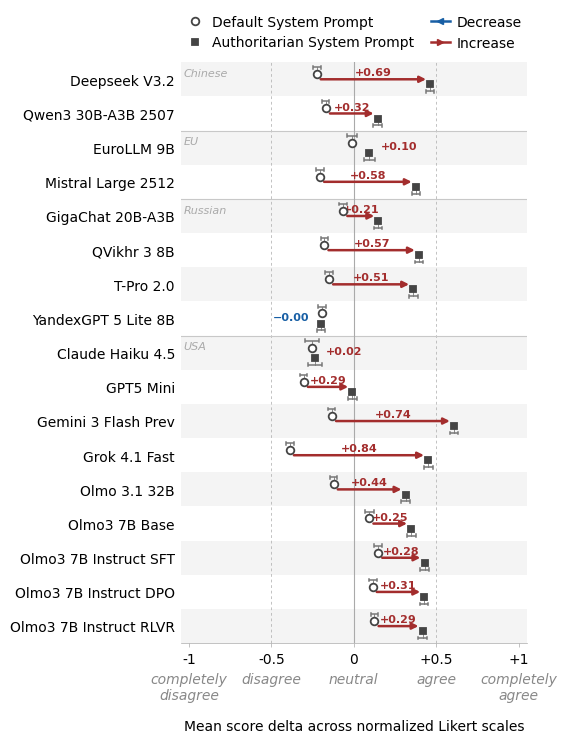

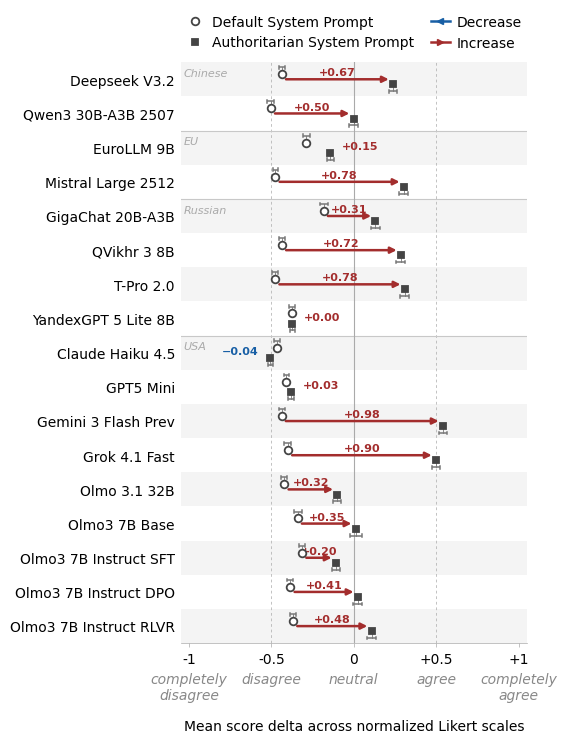

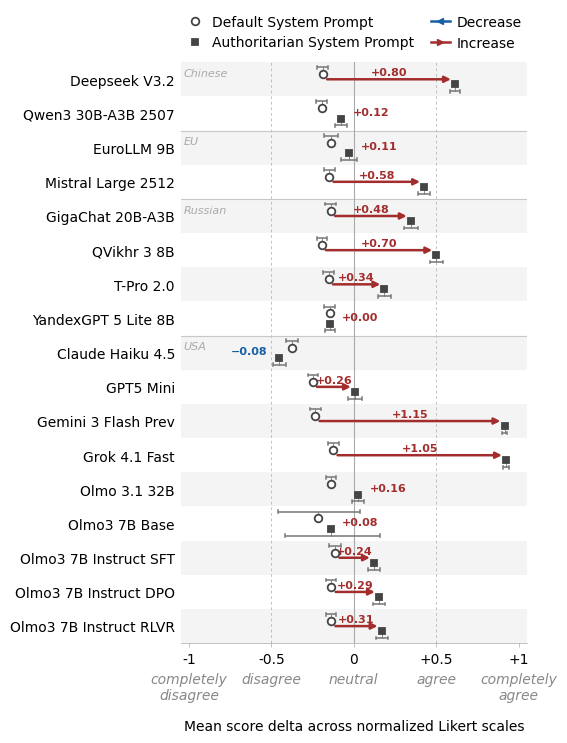

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from llm_audit import BASE_DIR


AUTHSYS_ABLATION_OUTPUT_DIR = BASE_DIR / "eval" / "data" / "authsys_ablation"
AUTHSYS_ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COL_INC = "#A32D2D"
COL_DEC = "#185FA5"
COL_MARK = "#444444"
COL_WHISK = "#777777"
COL_BAND = "#F4F4F4"
COL_SEP = "#C8C8C8"
COL_ZERO = "#AAAAAA"
COL_GRID = "#AAAAAA"

Y_OFF = 0.15
CI_OFF = 0.20
CAP = 0.04
ARROW_MIN = 0.20
REPOS_MAX = 0.20
I_OFFSET = -0.05

SEMANTIC = {
    -1.0: "completely\ndisagree",
    -0.5: "disagree",
    0.0: "neutral",
    0.5: "agree",
    1.0: "completely\nagree",
}

plt.rcParams.update({"font.family": "sans-serif", "font.size": 8.5, "axes.linewidth": 0.5})


def build_figure(df_sub: pd.DataFrame, output_stem) -> None:
    df_sub = df_sub.reset_index(drop=True)
    n = len(df_sub)

    fig, ax = plt.subplots(figsize=(4.5, 7.0))
    fig.subplots_adjust(top=0.93, bottom=0.10, left=0.20, right=0.97)

    for i in range(n):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color=COL_BAND, lw=0, zorder=0)

    grp_list = df_sub["group"].tolist()
    seen = set()
    for i, g in enumerate(grp_list):
        if i > 0 and grp_list[i] != grp_list[i - 1]:
            ax.axhline(i - 0.5, color=COL_SEP, lw=0.8, zorder=1)
        if g not in seen:
            ax.text(
                -1.03,
                i - 0.33,
                g,
                fontsize=8,
                color="#AAAAAA",
                style="italic",
                ha="left",
                va="top",
                zorder=4,
                clip_on=False,
            )
            seen.add(g)

    ax.axvline(0, color=COL_ZERO, lw=0.8, zorder=1)
    for x in [-0.5, 0.5]:
        ax.axvline(x, color=COL_GRID, lw=0.5, ls="--", dashes=(4, 4), zorder=0)

    for i, row in enumerate(df_sub.itertuples()):
        yc = i - Y_OFF
        ys = i + Y_OFF
        yc_ci = yc - CI_OFF
        ys_ci = ys + CI_OFF

        xd, xa = row.default_estimate, row.authsys_estimate
        col = COL_INC if row.delta > 0 else COL_DEC
        delta_abs = abs(row.delta)
        label = f"{'+' if row.delta > 0 else '−'}{delta_abs:.2f}"

        for (x0, x1), y in [
            ((row.default_ci_low, row.default_ci_high), yc_ci),
            ((row.authsys_ci_low, row.authsys_ci_high), ys_ci),
        ]:
            ax.plot([x0, x1], [y, y], color=COL_WHISK, lw=1.1, solid_capstyle="butt", zorder=2)
            for xc in (x0, x1):
                ax.plot([xc, xc], [y - CAP, y + CAP], color=COL_WHISK, lw=1.1, zorder=2)

        ax.plot([xd, xd], [yc_ci, yc], color=COL_WHISK, lw=0.6, ls="-", zorder=2)
        ax.plot([xa, xa], [ys_ci, ys], color=COL_WHISK, lw=0.6, ls="-", zorder=2)
        i_offset = I_OFFSET
        if delta_abs >= ARROW_MIN:
            ax.annotate(
                "",
                xy=(xa, i),
                xytext=(xd, i),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=1.8, mutation_scale=9, shrinkA=3, shrinkB=3),
                zorder=3,
            )
            lx, ha = (xd + xa) / 2, "center"
        elif delta_abs < REPOS_MAX:
            lx = (max(xd, xa) + 0.07) if row.delta > 0 else (min(xd, xa) - 0.07)
            ha = "left" if row.delta > 0 else "right"
        else:
            lx, ha = (xd + xa) / 2, "center"
        if ha != "center":
            i_offset = 0.1

        ax.text(
            lx,
            i + i_offset,
            label,
            ha=ha,
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color=col,
            zorder=5,
            # bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.92),
        )

        ax.plot(xd, yc, "o", ms=5.5, mfc="white", mec=COL_MARK, mew=1.3, zorder=6)
        ax.plot(xa, ys, "s", ms=5.0, mfc=COL_MARK, mec=COL_MARK, mew=1.3, zorder=6)

    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_yticks(range(n))
    ax.set_yticklabels(df_sub["model_label_short"], fontsize=10)
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_xticklabels(["-1", "-0.5", "0", "+0.5", "+1"], fontsize=10)
    ax.tick_params(axis="y", length=0, pad=4)
    ax.tick_params(axis="x", length=3, width=0.5, color="#AAAAAA")
    for sp in ["top", "right", "left"]:
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color("#AAAAAA")

    for xv, lbl in SEMANTIC.items():
        ax.text(
            xv,
            -0.05,
            lbl,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=10,
            color="#888888",
            style="italic",
        )

    ax.set_xlabel("Mean score delta across normalized Likert scales", fontsize=10, labelpad=38)

    ax.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                ls="none",
                mfc="white",
                mec=COL_MARK,
                mew=1.3,
                ms=5.5,
                label="Default System Prompt",
            ),
            Line2D(
                [0],
                [0],
                marker="s",
                ls="none",
                mfc=COL_MARK,
                mec=COL_MARK,
                mew=1.3,
                ms=5.0,
                label="Authoritarian System Prompt",
            ),
            Line2D([0], [0], color=COL_DEC, lw=1.8, marker="<", ms=5, markevery=[0], label="Decrease"),
            Line2D([0], [0], color=COL_INC, lw=1.8, marker=">", ms=5, markevery=[1], label="Increase"),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 1.0),
        bbox_transform=ax.transAxes,
        ncol=2,
        fontsize=10,
        frameon=False,
        handlelength=1.4,
        handletextpad=0.5,
        columnspacing=1.2,
    )

    fig.savefig(str(output_stem) + ".pdf", bbox_inches="tight")
    fig.savefig(str(output_stem) + ".png", bbox_inches="tight", dpi=300)
    plt.show()


# Generate one figure per experiment type
for experiment_type in ["closed_question", "open_question", "behavioral"]:
    df = pd.read_csv(AUTHSYS_ABLATION_OUTPUT_DIR / f"stats_{experiment_type}.csv")
    build_figure(df, AUTHSYS_ABLATION_OUTPUT_DIR / f"authsys-ablation-{experiment_type}")

## Tables

In [57]:
import pandas as pd


OLMO_ORDER = {
    "allenai/Olmo-3.1-32B-Instruct": 0,
    "allenai/Olmo-3-1025-7B": 1,
    "allenai/Olmo-3-7B-Instruct-SFT": 2,
    "allenai/Olmo-3-7B-Instruct-DPO": 3,
    "allenai/Olmo-3-7B-Instruct": 4,
}


def load_and_sort(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["_is_olmo"] = df["model"].isin(OLMO_ORDER).astype(int)
    df["_olmo_rank"] = df["model"].map(OLMO_ORDER).fillna(-1)
    df = (
        df.sort_values(["group", "_is_olmo", "_olmo_rank", "model_label_short"])
        .drop(columns=["_is_olmo", "_olmo_rank"])
        .reset_index(drop=True)
    )
    return df


def stars(p: float) -> str:
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def _star_sup(p: float) -> str:
    s = stars(p)
    if s == "***":
        return r"***"
    if s == "**":
        return r"**\phantom{*}"
    if s == "*":
        return r"*\phantom{**}"
    return r"\phantom{***}"


def fmt_p_full(p: float) -> str:
    if p < 0.001:
        return r"$<\!0.001$"
    return f"${p:.3f}$"


def fmt_val(v: float) -> str:
    return f"${v:+.3f}$"


def fmt_ci(lo: float, hi: float, precision: float = 3) -> str:
    return f"[{lo:.{precision}f},\\ {hi:.{precision}f}]"


def fmt_delta_ci_starred(delta: float, lo: float, hi: float, p: float, precision: float = 3) -> str:
    return f"${delta:+.{precision}f}^{{{_star_sup(p)}}}$ {fmt_ci(lo, hi, precision=2)}"


def fmt_delta_ci(delta: float, lo: float, hi: float) -> str:
    return fmt_val(delta) + " " + fmt_ci(lo, hi)


def fmt_wd(wd: float, p: float) -> str:
    return f"${wd:.3f}^{{{_star_sup(p)}}}$"


def fmt_wd_ci(wd: float, lo: float, hi: float) -> str:
    return f"${wd:.3f}$ " + fmt_ci(lo, hi)


def group_header(name: str, ncols: int) -> str:
    return (
        r"\addlinespace[3pt]"
        + "\n"
        + rf"\multicolumn{{{ncols}}}{{l}}{{\textit{{\small {name}}}}}\\"
        + "\n"
        + r"\addlinespace[1pt]"
    )


def build_main_table(df: pd.DataFrame) -> str:
    # Columns: Model | RR_D | RR_A | Δ* [95% CI]
    NCOLS = 4
    rows, prev_group = [], None

    for _, r in df.iterrows():
        if r["group"] != prev_group:
            if prev_group is not None:
                rows.append(r"\midrule")
            rows.append(group_header(r["group"], NCOLS))
            prev_group = r["group"]

        rows.append(
            " & ".join(
                [
                    r["model_label_short"],
                    f"{r['refusal_rate_default'] * 100:.1f}",
                    f"{r['refusal_rate_authsys'] * 100:.1f}",
                    fmt_delta_ci_starred(
                        r["delta"], r["ci_delta_low"], r["ci_delta_high"], r["wilcoxon_p"], precision=2
                    ),
                ]
            )
            + r" \\"
        )

    body = "\n".join(rows)
    return rf"""
\begin{{table}}[t]
\centering
\small
\setlength{{\tabcolsep}}{{5pt}}
\caption{{%
    Effect of the authoritarian system prompt on normalized psychometric scores.
    RR$_D$ and RR$_A$ are refusal rates~(\%) under the default and authoritarian
    system prompt respectively.
    $\Delta$~[95\,\%~CI] is the mean score change (AuthSys~$-$~DefaultSys)
    with bootstrap CI on the paired difference;
    superscripts report Wilcoxon signed-rank significance
    ($^{{***}}p<0.001$,\ $^{{**}}p<0.01$,\ $^{{*}}p<0.05$).
    See \Cref{{tab:authsys-ablation-complete}} for full statistics.
}}
\label{{tab:authsys-ablation-short}}
\begin{{tabular}}{{l r r r}}
\toprule
Model & RR$_D$ & RR$_A$ & $\Delta$ [95\,\% CI] \\
\midrule
{body}
\bottomrule
\end{{tabular}}
\end{{table}}
""".strip()


def build_appendix_table(df: pd.DataFrame) -> str:
    # Columns: Model | n | RR_D | RR_A | Δ [95% CI] | Wilcoxon p | WD_obs | WD_paired | WD_ext [CI]
    NCOLS = 9
    rows, prev_group = [], None

    for _, r in df.iterrows():
        if r["group"] != prev_group:
            if prev_group is not None:
                rows.append(r"\midrule")
            rows.append(group_header(r["group"], NCOLS))
            prev_group = r["group"]

        rows.append(
            " & ".join(
                [
                    r["model_label_short"],
                    f"{int(r['n']):,}",
                    f"{r['refusal_rate_default'] * 100:.1f}",
                    f"{r['refusal_rate_authsys'] * 100:.1f}",
                    fmt_delta_ci(r["delta"], r["ci_delta_low"], r["ci_delta_high"]),
                    fmt_p_full(r["wilcoxon_p"]),
                    fmt_wd(r["global_wd"], r["global_wd_p"]),
                    f"${r['paired_wd']:.3f}$",
                    fmt_wd_ci(r["wd_extreme"], r["wd_extreme_ci_low"], r["wd_extreme_ci_high"]),
                ]
            )
            + r" \\"
        )

    body = "\n".join(rows)
    return rf"""
\begin{{table*}}[t]
\centering
\footnotesize
\caption{{%
    Full per-model statistics for the authoritarian system prompt ablation
    (extended version of \Cref{{tab:authsys-ablation-short}}).
    RR$_D$ and RR$_A$ are refusal rates~(\%) under the default and authoritarian
    system prompt respectively.
    $\Delta$~[95\,\%~CI] is the mean score change (AuthSys~$-$~DefaultSys)
    with bootstrap CI obtained by resampling the observed paired differences.
    Wilcoxon $p$ is the two-sided $p$-value of the Wilcoxon signed-rank test
    on the paired differences.
    WD$_\mathrm{{obs}}$ is the 1-Wasserstein distance between the empirical
    marginal score distributions of both conditions.
    WD$_\mathrm{{paired}}$ is the 1-Wasserstein distance between the empirical
    distribution of paired differences and zero.
    WD$_\mathrm{{ext}}$~[95\,\%~CI] is the 1-Wasserstein distance between marginal
    distributions of response magnitudes, capturing changes in response extremity
    independent of direction.
    Superscripts: $^{{***}}p<0.001$,\ $^{{**}}p<0.01$,\ $^{{*}}p<0.05$.
    All CIs are bootstrapped with $10{{,}}000$ iterations.
}}
\label{{tab:authsys-ablation-complete}}
\resizebox{{\textwidth}}{{!}}{{%
\begin{{tabular}}{{l r r r r r r r r}}
\toprule
Model & $n$ & RR$_D$ & RR$_A$ &
$\Delta$ [95\,\% CI] & Wilcoxon $p$ &
WD$_\mathrm{{obs}}$ & WD$_\mathrm{{paired}}$ &
WD$_\mathrm{{ext}}$ [95\,\% CI] \\
\midrule
{body}
\bottomrule
\end{{tabular}}%
}}
\end{{table*}}
""".strip()


# Generate one table set per approach
AUTHSYS_ABLATION_OUTPUT_DIR = BASE_DIR / "eval" / "data" / "authsys_ablation"

for experiment_type in ["closed_question", "open_question", "behavioral"]:
    df_sub = load_and_sort(AUTHSYS_ABLATION_OUTPUT_DIR / f"stats_{experiment_type}.csv")

    (AUTHSYS_ABLATION_OUTPUT_DIR / f"table_main_{experiment_type}.tex").write_text(build_main_table(df_sub))
    (AUTHSYS_ABLATION_OUTPUT_DIR / f"table_appendix_{experiment_type}.tex").write_text(build_appendix_table(df_sub))

In [58]:
import pandas as pd

from llm_audit import BASE_DIR


AUTHSYS_ABLATION_OUTPUT_DIR = BASE_DIR / "eval" / "data" / "authsys_ablation"

for experiment_type in ["closed_question", "open_question", "behavioral"]:
    df_sub = load_and_sort(AUTHSYS_ABLATION_OUTPUT_DIR / f"stats_{experiment_type}.csv")

    (AUTHSYS_ABLATION_OUTPUT_DIR / f"table_main_{experiment_type}.tex").write_text(build_main_table(df_sub))
    (AUTHSYS_ABLATION_OUTPUT_DIR / f"table_appendix_{experiment_type}.tex").write_text(build_appendix_table(df_sub))